In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
beta = 0.01
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-10)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 64

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
etaCl_psi([customGrid_phi[31], customGrid_psi[31]])

3867.467214798724

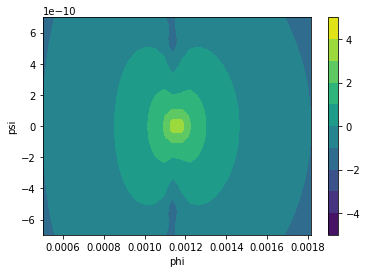

In [25]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

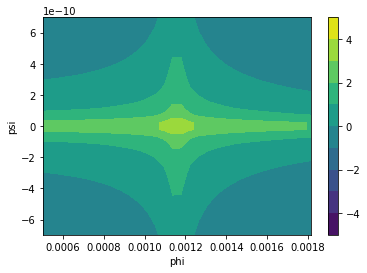

In [27]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

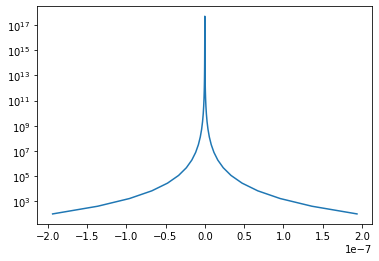

In [54]:
etaCls = np.zeros(nGrid)
for i in range(nGrid):
    etaCls[i] = etaCl_psi([phic, customGrid_psi[i]])

ax = plt.gca()
plt.plot(customGrid_psi, etaCls)
ax.set_yscale("log")
plt.show()

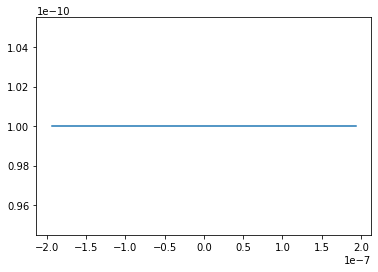

In [44]:
vDer2psi = np.zeros(nGrid)
for i in range(nGrid):
    vDer2psi[i] = infPotDeriv2Func_psi([phic, customGrid_psi[i]])

ax = plt.gca()
plt.plot(customGrid_psi, vDer2psi)
plt.show()

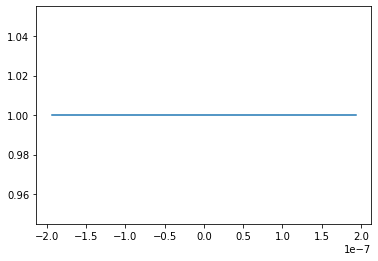

In [50]:
etapsi = np.zeros(nGrid)
for i in range(nGrid):
    etapsi[i] = eta_psi([phic, customGrid_psi[i]])

ax = plt.gca()
plt.plot(customGrid_psi, etapsi)
plt.show()

In [49]:
print(infPotDeriv2Func_psi([phic, 0]))
print(infPotFunc([phic, 0]))
print(eta_psi([phic, 0]))

9.313225746154785e-20
1e-10
9.313225746154785e-10


In [52]:
eta_psi([phic, customGrid_psi[30]])

1.2200325727462769e-07

In [9]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = np.linalg.eig(fpFinDiff_NeuDir)
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(eigVals_NeuDir)]
eigValsSort_NeuDir = np.sort(eigVals_NeuDir)

In [10]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

[[8.163753630657276e+24 -1.473764357651468e+02 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-3.088882507102868e+02 6.225170070645189e+24 -3.940704827106294e+02 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.601353154238539e+02 3.914536038401900e+24 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.342560971251348e+24 -7.931839005936029e+02 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -5.580265231959180e+02 2.289254703790285e+24 -4.242908259982001e+02]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -2.854069996409347e+02 3.372037654742988e+24]]


In [11]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

In [12]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

[[8.163753630657276e+24 -1.473764357651468e+02 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-3.088882507102868e+02 6.225170070645189e+24 -3.940704827106294e+02 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.601353154238539e+02 3.914536038401900e+24 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  1.342560971251348e+24 -7.931839005936029e+02 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -5.580265231959180e+02 2.289254703790285e+24 -4.242908259982001e+02]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -2.854069996409347e+02 3.372037654742988e+24]]


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


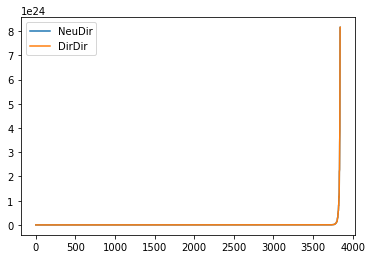

In [13]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

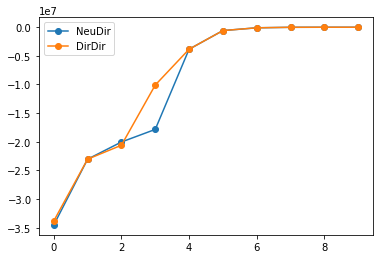

In [14]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuDir[:10], marker='o', label = "NeuDir")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-3.44992727e+07+0.j -2.30278443e+07+0.j -2.00333918e+07+0.j
 -1.78369134e+07+0.j -3.84957779e+06+0.j -5.96503253e+05+0.j
 -1.08542584e+05+0.j -2.21433553e+04+0.j -1.23995366e+04+0.j
 -1.23506649e+04+0.j]
[-3.38012218e+07+0.j -2.30278443e+07+0.j -2.05971136e+07+0.j
 -1.00975446e+07+0.j -3.84957779e+06+0.j -5.96503253e+05+0.j
 -1.08542584e+05+0.j -2.21433553e+04+0.j -1.23995366e+04+0.j
 -1.23506649e+04+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


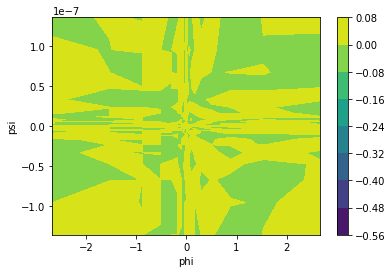

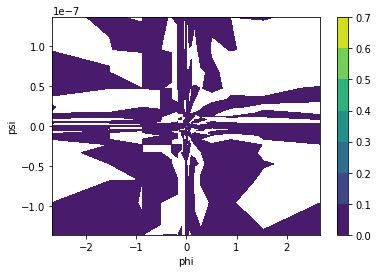

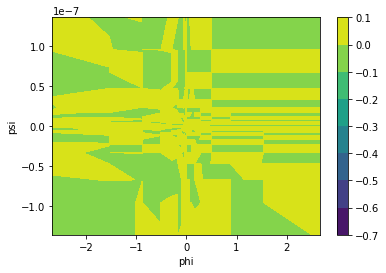

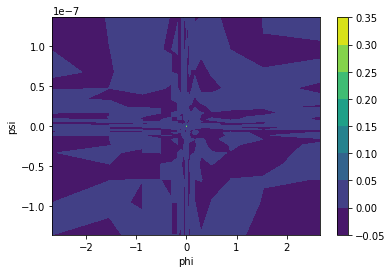

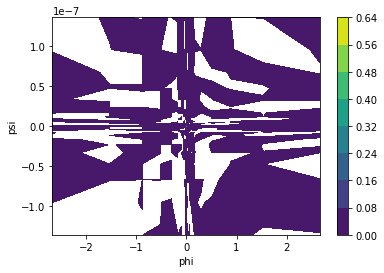

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    plt.show()

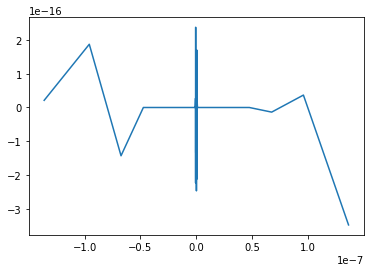

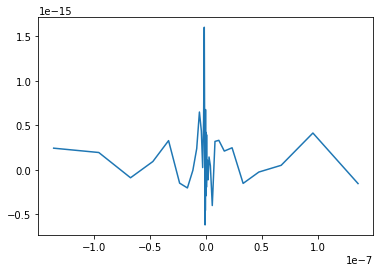

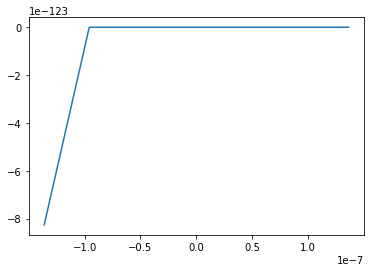

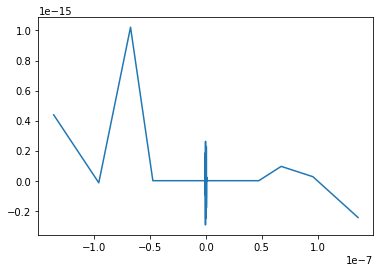

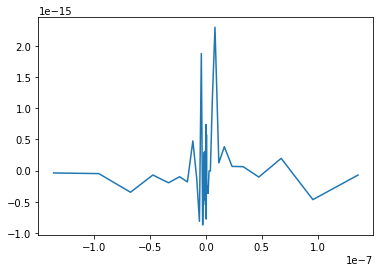

In [30]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[31,:])
    plt.show()

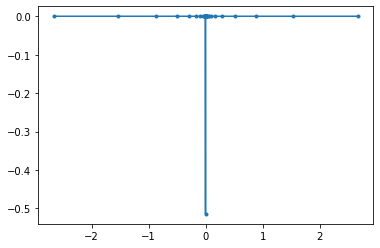

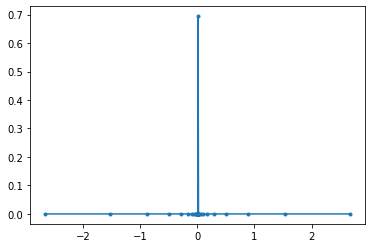

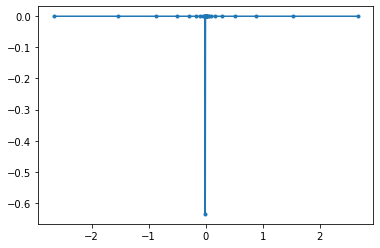

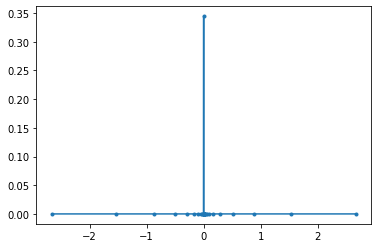

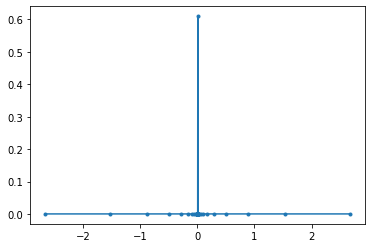

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    #ax.set_xlim(phiLargeEtaMin,phiLargeEtaMax)
    plt.show()

712 11 (-0.5143146198588805+0j)


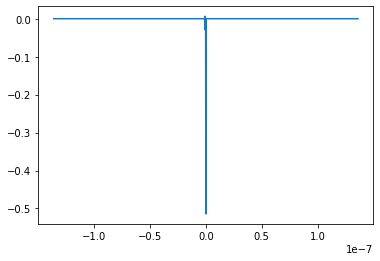

In [19]:
i = np.argmax(np.abs(eigVecsSort_NeuDir[0]))
print(i, i // (nGrid-2), eigVecsSort_NeuDir[0][i])

ax = plt.gca()
plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
# ax.set_xlim(psiLargeEtaMin,psiLargeEtaMax)
plt.show()

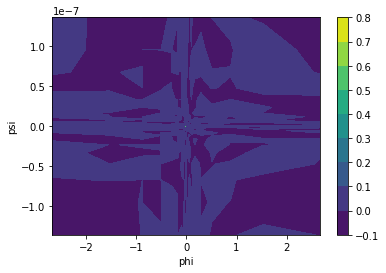

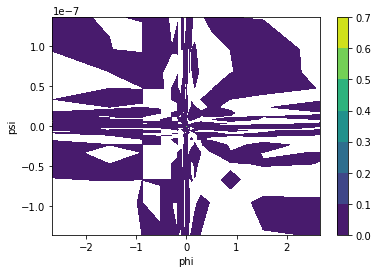

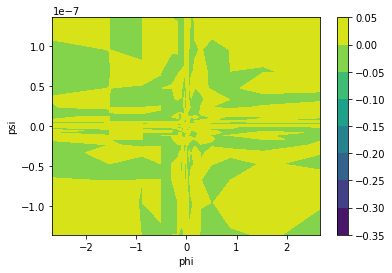

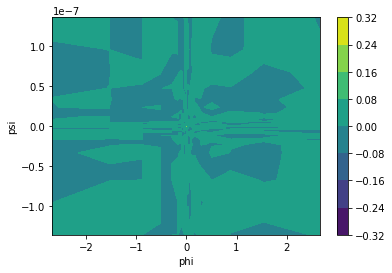

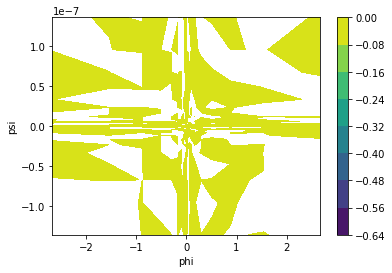

In [20]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    plt.show()

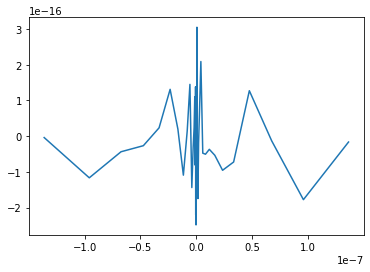

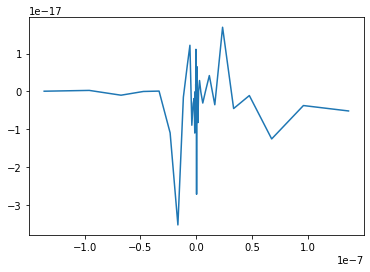

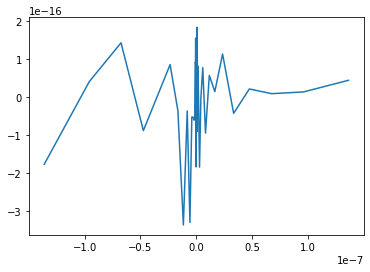

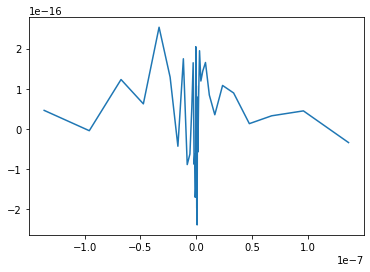

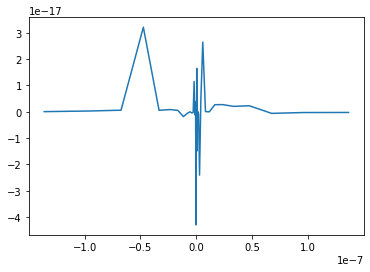

In [21]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

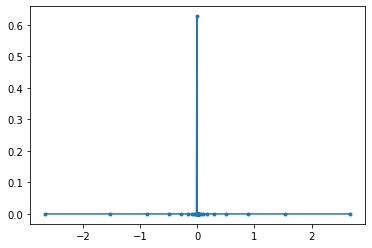

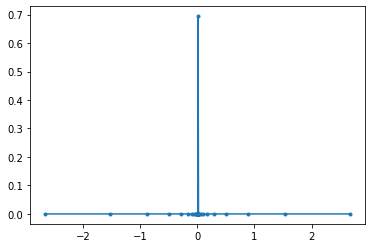

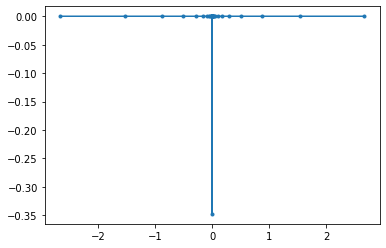

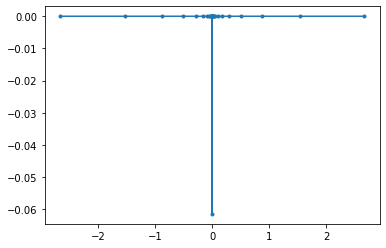

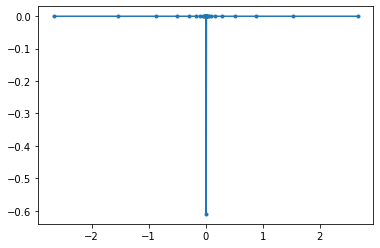

In [22]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

651 10 (0.7000910385969624+0j)


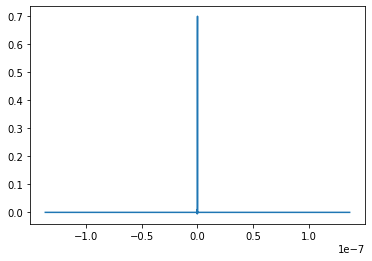

In [23]:
i = np.argmax(np.abs(eigVecsSort_DirDir[0]))
print(i, i // (nGrid-2), eigVecsSort_DirDir[0][i])

ax = plt.gca()
plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[0], (nGrid-2, nGrid-2))[i // (nGrid-2),:])
# ax.set_xlim(psiLargeEtaMin,psiLargeEtaMax)
plt.show()

In [32]:
# 局在した場所でスライスして1次元の問題として解く
infPotFunc_phiLoc = lambda psi: infPotFunc([phic, psi])
infPotDerivFunc_psi_phiLoc = lambda psi: infPotDerivFunc_psi([phic, psi])
infPotDeriv2Func_psi_phiLoc = lambda psi: infPotDeriv2Func_psi([phic, psi])

In [38]:
customGrid_psi_fine = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), 1001))[:-1],
                                      np.linspace(psiLargeEtaMin, psiLargeEtaMax, 2000),
                                      np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), 1001))[1:]])

fpFinDiff_phiLoc = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLoc,
    [infPotDerivFunc_psi_phiLoc],
    [infPotDeriv2Func_psi_phiLoc],
    [nGrid],
    [psimax],
    [psimin],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid_psi_fine],
    set0OutOfInfRegion=False
)

eigVals_phiLoc, eigVecs_NeuNeu_phiLoc = np.linalg.eig(fpFinDiff_phiLoc)
eigVecsSort_phiLoc = eigVecs_NeuNeu_phiLoc.T[np.argsort(eigVals_phiLoc)]
eigValsSort_phiLoc = np.sort(eigVals_phiLoc)

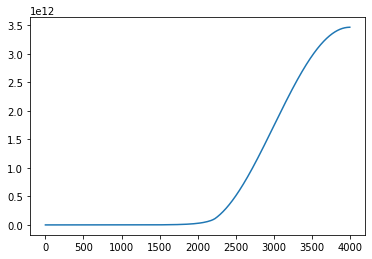

In [39]:
ax = plt.gca()
plt.plot(eigValsSort_phiLoc)
plt.show()

In [40]:
eigValsSort_phiLoc

array([2.77211720e+01, 1.10996098e+02, 2.49897290e+02, ...,
       3.46873496e+12, 3.46874567e+12, 3.46875209e+12])

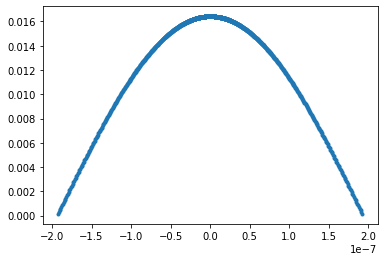

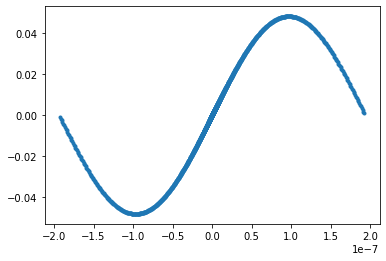

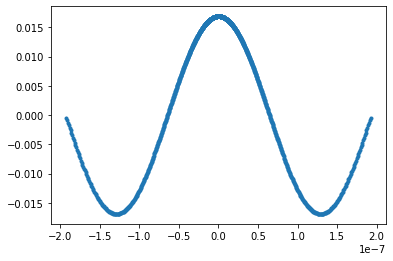

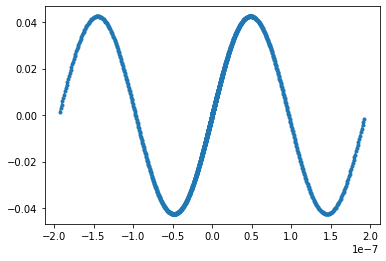

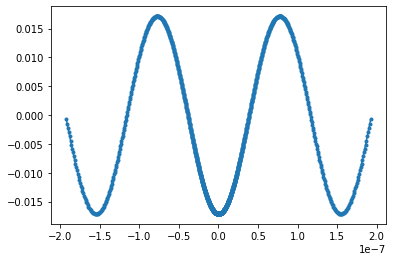

In [42]:
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid_psi_fine[1:-1], eigVecsSort_phiLoc[iEig], marker='.')
    plt.show()